In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.utils import to_categorical

In [2]:
columns = [
    'letter',
    'xbox','ybox','width','height',
    'onpix','xbar','ybar','x2bar','y2bar',
    'xybar','x2ybr','xy2br','xedge',
    'xedgey','yedge','yedgex'
]


In [3]:
data = pd.read_csv(
    'letter-recognition.data',
    names=columns
)

# Display Dataset
print("First 5 Rows:")
print(data.head())

# Dataset Shape
print("\nDataset Shape:")
print(data.shape)

First 5 Rows:
  letter  xbox  ybox  width  height  onpix  xbar  ybar  x2bar  y2bar  xybar  \
0      T     2     8      3       5      1     8    13      0      6      6   
1      I     5    12      3       7      2    10     5      5      4     13   
2      D     4    11      6       8      6    10     6      2      6     10   
3      N     7    11      6       6      3     5     9      4      6      4   
4      G     2     1      3       1      1     8     6      6      6      6   

   x2ybr  xy2br  xedge  xedgey  yedge  yedgex  
0     10      8      0       8      0       8  
1      3      9      2       8      4      10  
2      3      7      3       7      3       9  
3      4     10      6      10      2       8  
4      5      9      1       7      5      10  

Dataset Shape:
(20000, 17)


In [4]:
X = data.drop('letter', axis=1)

y = data['letter']


In [5]:
encoder = LabelEncoder()

y = encoder.fit_transform(y)

In [6]:
y = to_categorical(y)

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)


In [8]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)

In [9]:
model = Sequential()

# Input Layer + Hidden Layer 1
model.add(Dense(
    128,
    activation='relu',
    input_shape=(X_train.shape[1],)
))

# Hidden Layer 2
model.add(Dense(64, activation='relu'))

# Hidden Layer 3
model.add(Dense(32, activation='relu'))

# Output Layer
model.add(Dense(26, activation='softmax'))


C:\Users\IFFA\Yahya\pythonProject1\.venv\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [10]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [11]:

history = model.fit(
    X_train,
    y_train,
    epochs=50,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)

Epoch 1/50
400/400 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.5509 - loss: 1.5843 - val_accuracy: 0.7253 - val_loss: 0.9248
Epoch 2/50
400/400 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.7861 - loss: 0.7175 - val_accuracy: 0.8134 - val_loss: 0.6462
Epoch 3/50
400/400 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.8398 - loss: 0.5398 - val_accuracy: 0.8484 - val_loss: 0.5187
Epoch 4/50
400/400 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8693 - loss: 0.4387 - val_accuracy: 0.8669 - val_loss: 0.4442
Epoch 5/50
400/400 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.8859 - loss: 0.3761 - val_accuracy: 0.8872 - val_loss: 0.3753
Epoch 6/50
400/400 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.9014 - loss: 0.3198 - val_accuracy: 0.8906 - val_loss: 0.3587
Epoch 7/50
400/400 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9120 - loss: 0.2827 - val_accuracy: 0.8947 - val_loss: 0.3326
Epoch 8/50
400/400 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.9212 - loss: 0.2548 - val_accuracy: 0.

In [13]:

loss, accuracy = model.evaluate(X_test, y_test)

print("\nTest Accuracy:", accuracy)

125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9548 - loss: 0.1779

Test Accuracy: 0.9547500014305115


In [14]:
predictions = model.predict(X_test)

predicted_classes = np.argmax(predictions, axis=1)

actual_classes = np.argmax(y_test, axis=1)

125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


In [15]:
print("\nSample Predictions:\n")

for i in range(10):
    predicted_letter = encoder.inverse_transform(
        [predicted_classes[i]]
    )[0]

    actual_letter = encoder.inverse_transform(
        [actual_classes[i]]
    )[0]

    print(
        "Predicted:", predicted_letter,
        "| Actual:", actual_letter
    )



Sample Predictions:

Predicted: T | Actual: T
Predicted: L | Actual: L
Predicted: A | Actual: A
Predicted: E | Actual: E
Predicted: Q | Actual: Q
Predicted: E | Actual: E
Predicted: O | Actual: O
Predicted: Q | Actual: Q
Predicted: G | Actual: G
Predicted: O | Actual: O


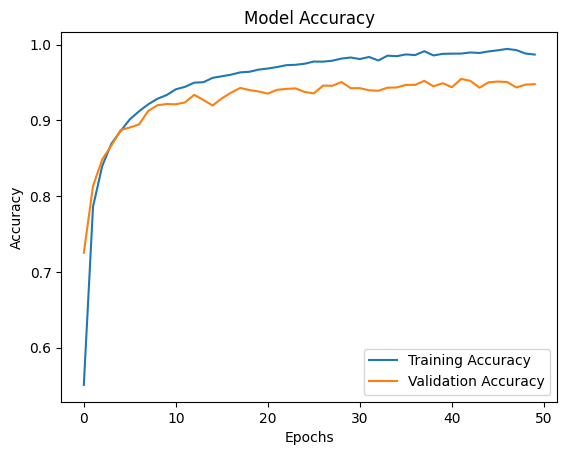

In [16]:
plt.plot(
    history.history['accuracy'],
    label='Training Accuracy'
)

plt.plot(
    history.history['val_accuracy'],
    label='Validation Accuracy'
)

plt.title('Model Accuracy')

plt.xlabel('Epochs')

plt.ylabel('Accuracy')

plt.legend()

plt.show()

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_error

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

# Load Dataset
data = pd.read_csv('housing.csv')

# Display Dataset
print(data.head())

# Features and Target
X = data.drop('MEDV', axis=1)
y = data['MEDV']

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# Feature Scaling
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Build Model
model = Sequential()

model.add(Dense(64, activation='relu', input_shape=(X_train.shape[1],)))
model.add(Dense(32, activation='relu'))
model.add(Dense(1))

# Compile Model
model.compile(
    optimizer='adam',
    loss='mse',
    metrics=['mae']
)

# Train Model
history = model.fit(
    X_train,
    y_train,
    epochs=100,
    batch_size=16,
    validation_split=0.2,
    verbose=1
)

# Prediction
y_pred = model.predict(X_test)

# Evaluation
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)

print("Mean Squared Error:", mse)
print("Mean Absolute Error:", mae)

# Plot Graph
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.title('Model Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')

plt.legend()
plt.show()